In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go



In [2]:
iot_dataset = pd.read_csv('iot_sensor_data.csv')
iot_dataset["Timestamp"] = pd.to_datetime(iot_dataset["Timestamp"])
iot_dataset["Date"] = iot_dataset["Timestamp"].dt.date
iot_dataset["Hour"] = iot_dataset["Timestamp"].dt.hour
iot_dataset

,Device_ID,Device_Type,Location,Status,Temperature_C,Humidity_%,Light_Lux,Motion_Count,Battery_Level_%,Timestamp,Date,Hour
0,D001,Light Sensor,Floor 1,Active,26.6,40.6,618.7,23,72.6,2025-09-01 00:00:00,2025-09-01,0
1,D002,Motion Sensor,Basement,Active,32.0,35.3,646.0,18,14.4,2025-09-01 01:00:00,2025-09-01,1
2,D003,Temperature Sensor,Lobby,Alert,23.4,37.2,481.7,7,57.9,2025-09-01 02:00:00,2025-09-01,2
3,D004,Light Sensor,Basement,Maintenance,33.2,57.6,762.8,30,96.6,2025-09-01 03:00:00,2025-09-01,3
4,D005,Light Sensor,Lobby,Alert,24.6,42.4,940.9,20,19.9,2025-09-01 04:00:00,2025-09-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...
195,D196,Humidity Sensor,Floor 3,Alert,20.9,63.9,223.1,33,52.3,2025-09-09 03:00:00,2025-09-09,3
196,D197,Humidity Sensor,Floor 2,Active,21.3,71.8,955.2,23,77.0,2025-09-09 04:00:00,2025-09-09,4
197,D198,Motion Sensor,Floor 2,Maintenance,18.7,85.3,501.4,14,88.5,2025-09-09 05:00:00,2025-09-09,5
198,D199,Temperature Sensor,Floor 2,Active,20.9,72.4,266.6,37,49.0,2025-09-09 06:00:00,2025-09-09,6


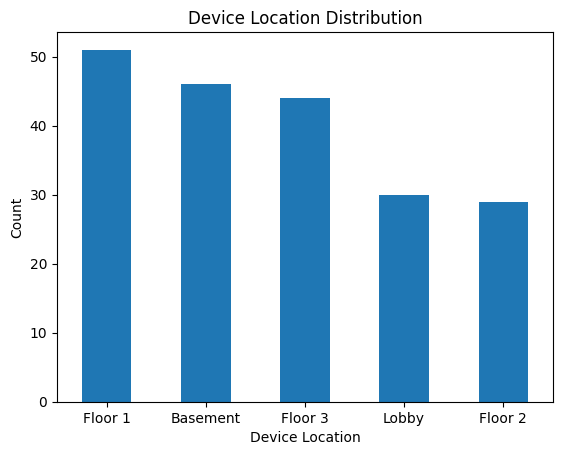

In [3]:
# Splicing the Dataset = Device Distribution by Location

dev_loc_count = iot_dataset['Location'].value_counts()

dev_loc_count.plot(kind='bar')
plt.title("Device Location Distribution")
plt.xlabel("Device Location")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

# Bar Chart is often use for comparison between two or more variables.
# It is easy to visualize and are familiar to other viewers

In [4]:
# Splicing the Dataset = Environmental Conditions – Humidity

hourly_humidity = (
    iot_dataset.groupby(["Date", "Hour"])["Humidity_%"]
    .mean()
    .reset_index()
)

plot = px.line(
    hourly_humidity,
    x="Hour",
    y="Humidity_%",
    facet_col="Date",
    facet_col_wrap=3,
    markers=True,
    title="Average Hourly Humidity per Day"
)

plot.update_yaxes(title="")
plot.update_xaxes(title="")
plot.show()



In [5]:
# Splicing the Dataset = Environmental Conditions – Light Intensity

hourly_light = (
    iot_dataset.groupby(["Date", "Hour"])["Light_Lux"]
    .mean()
    .reset_index()
)

plot = px.line(
    hourly_light,
    x="Hour",
    y="Light_Lux",
    facet_col="Date",
    facet_col_wrap=3,
    markers=True,
    title="Average Hourly Light_Lux per Day"
)

plot.update_yaxes(title="")
plot.update_xaxes(title="")
plot.show()


In [6]:
# Splicing the Dataset = Environmental Conditions – Battery vs Temperature
hourly_temp_vs_bat = (iot_dataset.groupby(["Date", "Hour"])[["Temperature_C", "Battery_Level_%"]]
    .mean()
    .reset_index()
)

# Melt the dataframe so Temp & Battery appear as categories
melted = hourly_temp_vs_bat.melt(
    id_vars=["Date", "Hour"],
    value_vars=["Temperature_C", "Battery_Level_%"],
    var_name="Variable",
    value_name="Value"
)

# Plot as grouped bar chart
plot = px.bar(
    melted,
    x="Hour",
    y="Value",
    facet_col_wrap=2,
    color="Variable",
    barmode="group",
    facet_col="Date",        # one subplot per day
    title="Average Hourly Temperature vs Battery per Day (Bar Chart)"
)

plot.update_layout(
    width=1200,   # wider
    height=2000
)
plot.show()


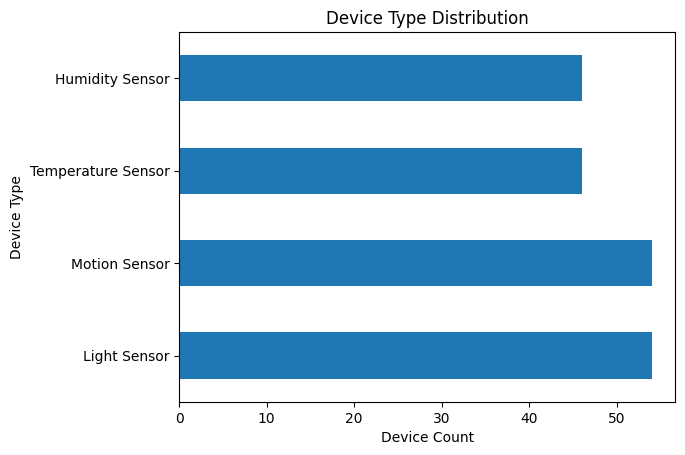

In [7]:
dev_type_count = iot_dataset['Device_Type'].value_counts()

dev_type_count.plot(kind='barh')
plt.title("Device Type Distribution")
plt.xlabel("Device Count")
plt.xticks(rotation=0)
plt.ylabel("Device Type")
plt.show()
